In [4]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [5]:
df = pd.read_csv("../../dataset/Stock_Data.csv")
df

,Open,Close,High,Low,Volume,RSI,MACD,Bollinger_Upper,Bollinger_Lower,Sentiment_Score,GDP_Growth,Inflation_Rate,Target
0,0.374639,0.374780,0.373510,0.378390,0.298909,0.847286,0.741715,0.367146,0.366420,0.877177,0.580868,0.038604,0
1,0.950982,0.937746,0.938422,0.946158,0.094805,0.494543,0.881343,0.938396,0.935640,0.907192,0.527044,0.108908,0
2,0.732198,0.719825,0.723644,0.723158,0.126348,0.195471,0.463179,0.710666,0.702300,0.378363,0.351052,0.432540,0
3,0.598823,0.599865,0.596973,0.605322,0.180662,0.736684,0.289076,0.593793,0.586936,0.231614,0.493274,0.946349,0
4,0.156053,0.163410,0.155891,0.166084,0.203646,0.418698,0.318761,0.164158,0.156355,0.191642,0.365116,0.074867,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.857897,0.859975,0.861524,0.856446,0.622456,0.966199,0.594471,0.849929,0.840819,0.792318,0.710992,0.001473,0
9996,0.897761,0.878667,0.890056,0.884459,0.226187,0.373257,0.946895,0.869530,0.880097,0.779265,0.117133,0.289775,0
9997,0.946975,0.933110,0.933244,0.942894,0.749012,0.304687,0.921183,0.923119,0.931122,0.674460,0.631873,0.432304,0
9998,0.397593,0.398947,0.393733,0.404212,0.521017,0.407382,0.200310,0.392947,0.403681,0.499445,0.013172,0.023832,0


## Visualize Dataset

### Target Distribution Analysis

/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_77824/1642022525.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Target', data=df, palette='Set1')


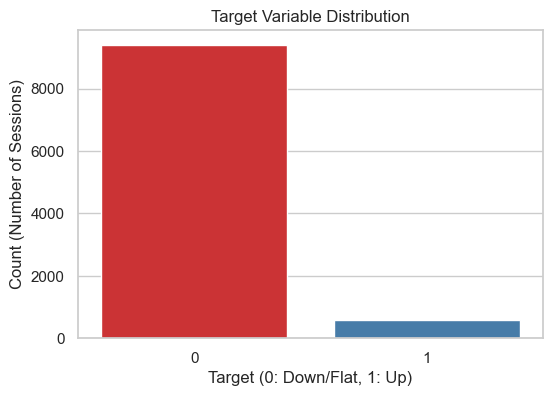

In [11]:
# Set the plotting style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6,4))
sns.countplot(x='Target', data=df, palette='Set1')
plt.title('Target Variable Distribution')
plt.xlabel('Target (0: Down/Flat, 1: Up)')
plt.ylabel('Count (Number of Sessions)')
plt.show()

### Correlation Matrix Heatmap

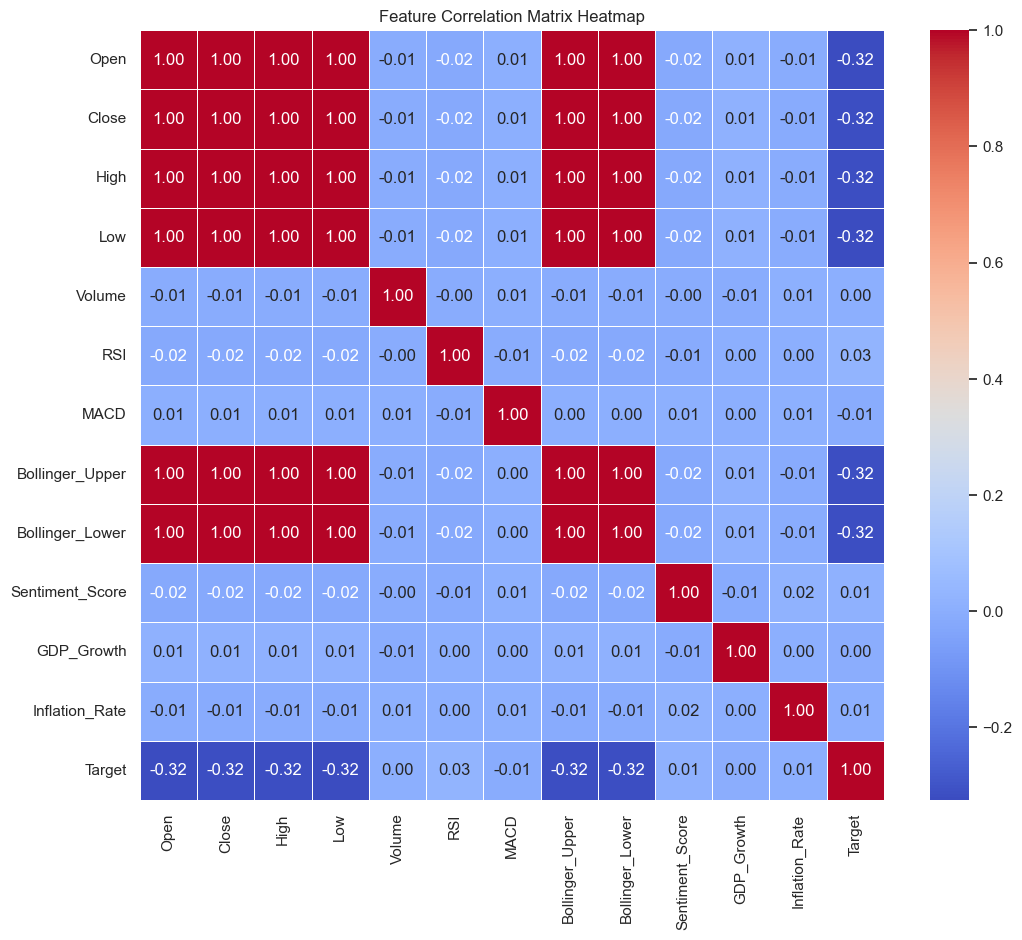

In [10]:
plt.figure(figsize=(12,10))
# Calculate Pearson correlation matrix
corr_matrix = df.corr()

# Generate the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix Heatmap')
plt.show()

### Feature Behavior by Target Class (Boxplots)

/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_77824/2648370508.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, ax=axes[i], palette='Pastel1')
/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_77824/2648370508.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, ax=axes[i], palette='Pastel1')
/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_77824/2648370508.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, ax=axes[i], palet

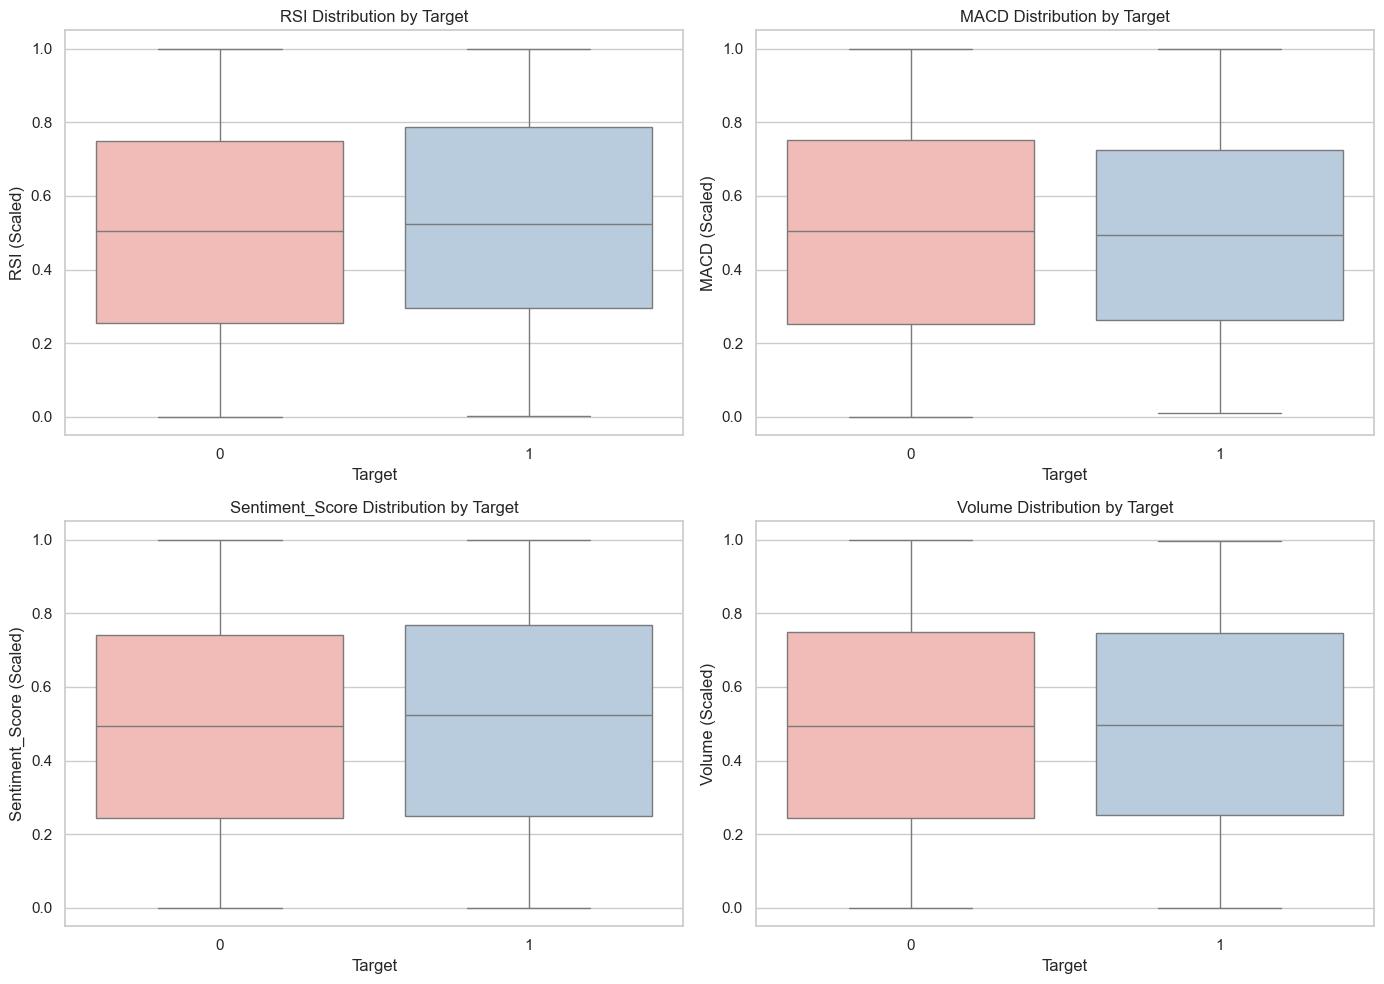

In [13]:
# Select key representative features for analysis
features_to_plot = ["RSI", "MACD", "Sentiment_Score", "Volume"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.boxplot(x='Target', y=col, data=df, ax=axes[i], palette='Pastel1')
    axes[i].set_title(f'{col} Distribution by Target')
    axes[i].set_xlabel('Target')
    axes[i].set_ylabel(f'{col} (Scaled)')

plt.tight_layout()
plt.show()


### 2D Feature Interaction & Decision Space

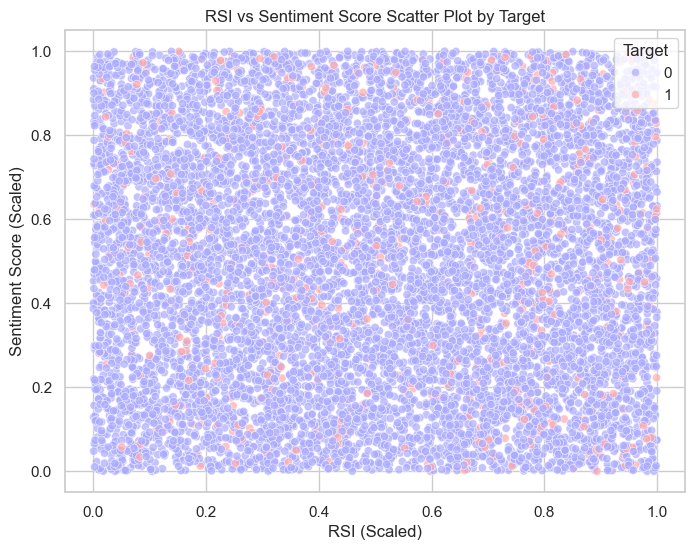

In [14]:
plt.figure(figsize=(8, 6))

# Plot the scatter distribution colored by Target
sns.scatterplot(x='RSI', y='Sentiment_Score', hue='Target', data=df, palette='bwr', alpha=0.7)
plt.title('RSI vs Sentiment Score Scatter Plot by Target')
plt.xlabel('RSI (Scaled)')
plt.ylabel('Sentiment Score (Scaled)')
plt.legend(title='Target')
plt.show()

### Time-Series Price Trend and Target Overlay

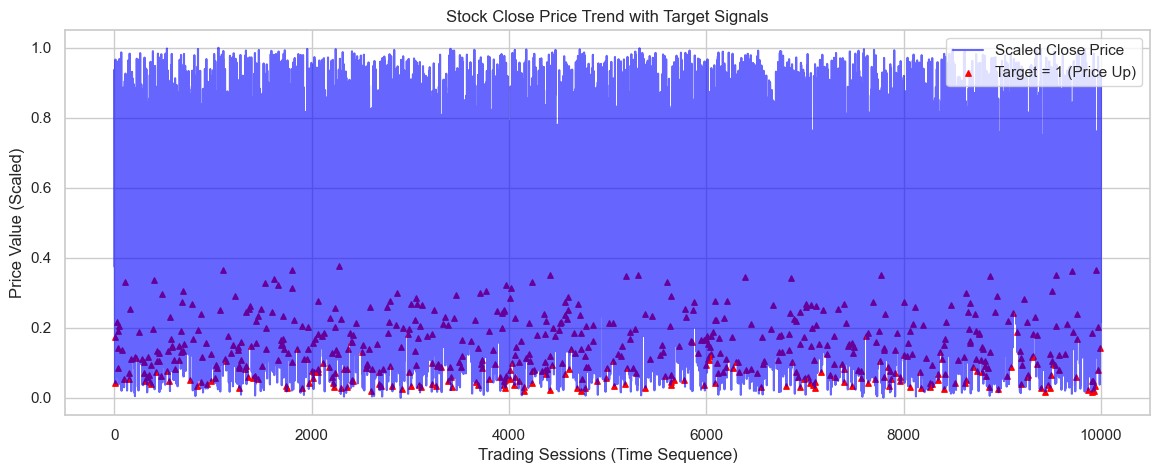

In [15]:
plt.figure(figsize=(14, 5))

# Plot the continuous scaled Close price
plt.plot(df['Close'], label='Scaled Close Price', color='blue', alpha=0.6)

# Overlay the positive target signals (Price Up) as red triangles
up_signals = df[df['Target'] == 1]
plt.scatter(up_signals.index, up_signals['Close'], color='red', marker='^', label='Target = 1 (Price Up)', s=15)

plt.title('Stock Close Price Trend with Target Signals')
plt.xlabel('Trading Sessions (Time Sequence)')
plt.ylabel('Price Value (Scaled)')
plt.legend()
plt.show()